# Catalyst distance analysis

How far apart are five phosphine catalysts **from each other**, and how far is each from the
**Kraken population** of 1,223 monodentate organophosphorus ligands, measured separately in
each of the project's feature sets.

Two different questions, two different tools:

| Question | Measure | Package |
|---|---|---|
| How similar are these five to each other? | pairwise euclidean / cosine, hierarchical clustering | `sklearn.metrics.pairwise_distances`, `scipy.cluster.hierarchy` |
| Is a catalyst typical of Kraken, or an outlier? | leverage, Mahalanobis, k-NN distance | `numpy`, `sklearn.covariance`, `sklearn.neighbors` |

The second group is the standard **applicability domain (AD)** toolkit from the QSAR
literature -- the accepted way to ask whether a query compound is close enough to a reference
set for a model trained on that set to be trusted:

* **Leverage** `h = x'(X'X)^-1 x`, the classic Williams-plot measure. It is proportional to
  the Mahalanobis distance from the training centroid. The usual warning threshold is
  `h* = 3(M+1)/N` for M descriptors and N reference compounds.
* **Mahalanobis distance** to the Kraken centroid, which accounts for descriptor covariance
  rather than treating every direction as equally important. Reported both from the ordinary
  covariance and from `MinCovDet` (robust, so a handful of extreme ligands cannot inflate it).
* **k-NN distance**, the mean distance to the k nearest Kraken ligands -- a local measure that
  catches a compound sitting in a sparse region even if it is near the global centroid.
  Reported as a percentile of the Kraken population so the number is interpretable.

Everything is computed on **standardised** descriptors (`StandardScaler` fitted on all 1,223
Kraken ligands), because the raw descriptors are in different units -- percent, Debye, eV --
and euclidean distance on raw values would just measure whichever column has the largest range.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# The Kraken table and the fitted reference PCA live in the hazel project; every
# project shares them unrefitted, so the feature sets mean the same thing here.
PROJECT = Path.cwd() / "gp_collab_hazel"
if not PROJECT.exists():
    PROJECT = Path.cwd().parent / "gp_collab_hazel"
sys.path.insert(0, str(PROJECT))

from gpc.config import TWO, FIVE          # noqa: E402
from gpc.data import load_bundle          # noqa: E402

reactions, ligands, reference, prepared = load_bundle(PROJECT / "inputs")
print(f"Kraken reference: {len(ligands)} ligands x {len(reference.columns)} descriptors")

Kraken reference: 1223 ligands x 190 descriptors


## The catalysts and the feature sets

Kraken ids verified against `kraken_identifiers.csv` by name and canonical SMILES.
`ligand_ohe` is deliberately absent: it has no descriptors, so distance is undefined -- every
ligand is equidistant from every other by construction.

In [2]:
CATALYSTS = {
    "(tBu)3P":   8,     # PtBu3      -- trialkyl
    "XPhos":     1,     # Xphos      -- dialkylbiaryl
    "SPhos":     3,     # SPhos      -- dialkylbiaryl
    "RuPhos":    4,     # RuPhos     -- dialkylbiaryl
    "BrettPhos": 102,   # BrettPhos  -- dialkylbiaryl
}

FEATURE_SETS = {
    "selected_2": list(TWO),
    "selected_5": list(FIVE),
    "pc_top":     list(reference.top_features),
    "pc_scores":  ["PC1", "PC2", "PC3", "PC4"],
}

missing = [n for n, i in CATALYSTS.items() if i not in set(ligands.kraken_id)]
assert not missing, f"not in the Kraken table: {missing}"

for name, cols in FEATURE_SETS.items():
    shown = cols if len(cols) <= 5 else cols[:4] + ["..."]
    print(f"  {name:11s} {len(cols):2d} descriptors: {shown}")

  selected_2   2 descriptors: ['vbur_pct_boltz', 'vbur_pct_min']
  selected_5   5 descriptors: ['vbur_pct_boltz', 'vbur_pct_min', 'vbur_pct_delta', 'dipolemoment_boltz', 'homo_lumo_gap_eV']
  pc_top      12 descriptors: ['vbur_vtot_boltz', 'volume_boltz', 'vbur_near_vtot_vburminconf', 'pyr_P_max', '...']
  pc_scores    4 descriptors: ['PC1', 'PC2', 'PC3', 'PC4']


In [3]:
def standardised(cols):
    """Kraken descriptors -> mean-imputed, z-scored on the full population.

    The scaler is fitted on all 1,223 ligands, not on the five queries, so a
    distance means "how unusual is this within Kraken".
    """
    X = ligands[cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    X = pd.DataFrame(SimpleImputer(strategy="mean").fit_transform(X),
                     columns=cols, index=ligands.kraken_id)
    Z = pd.DataFrame(StandardScaler().fit_transform(X.values), columns=cols, index=X.index)
    query = Z.loc[list(CATALYSTS.values())].copy()
    query.index = list(CATALYSTS)
    return Z, query


def population_distance(Z, query, k=5):
    """Applicability-domain measures for each query against the Kraken population."""
    M, N = Z.shape[1], len(Z)

    # Leverage, the Williams-plot measure. pinv keeps it stable if the descriptor
    # block is rank-deficient (pc_top holds near-duplicate size measures).
    gram = np.linalg.pinv(Z.values.T @ Z.values)
    leverage = np.einsum("ij,jk,ik->i", query.values, gram, query.values)
    h_star = 3 * (M + 1) / N

    maha_emp = np.sqrt(EmpiricalCovariance().fit(Z.values).mahalanobis(query.values))
    # random_state fixed so the robust fit is reproducible run to run
    maha_rob = np.sqrt(MinCovDet(random_state=0).fit(Z.values).mahalanobis(query.values))

    nn = NearestNeighbors(n_neighbors=k + 1).fit(Z.values)
    d_query, _ = nn.kneighbors(query.values)
    d_ref, _ = nn.kneighbors(Z.values)
    knn_query = d_query[:, 1:].mean(axis=1)      # column 0 is the point itself
    knn_ref = d_ref[:, 1:].mean(axis=1)
    percentile = [100.0 * (knn_ref < v).mean() for v in knn_query]

    return pd.DataFrame({
        "leverage": leverage,
        "outside_AD": leverage > h_star,
        "mahalanobis": maha_emp,
        "mahalanobis_robust": maha_rob,
        f"knn{k}_distance": knn_query,
        "knn_percentile": percentile,
    }, index=query.index), h_star

## 1. How far apart are the five from each other?

Euclidean distance in standardised descriptor space. Cosine is shown alongside because it
compares *direction* rather than magnitude -- two ligands can be similar in character while
differing in overall size, and cosine will say so where euclidean will not.

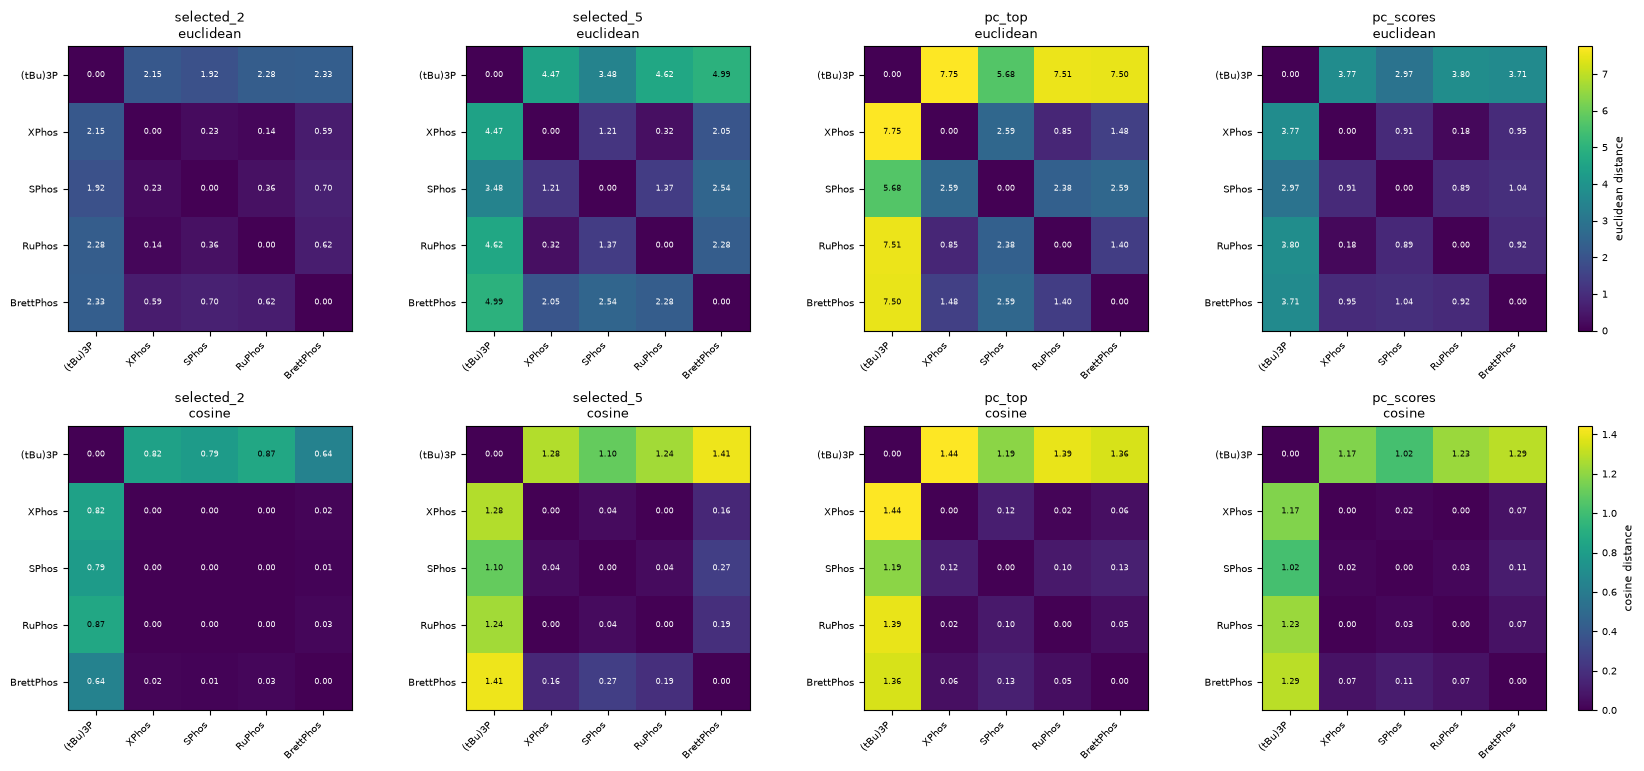

In [4]:
plt.close("all")
results = {}

# Built first so each row can share one colour scale across the feature sets.
# The scale is shared per METRIC, not across both rows: euclidean here runs to
# ~8 while cosine is bounded near 2, so one scale over both would flatten the
# cosine row into a single colour and say nothing.
for name, cols in FEATURE_SETS.items():
    Z, query = standardised(cols)
    results[name] = {"Z": Z, "query": query}
    for metric in ("euclidean", "cosine"):
        results[name][metric] = pd.DataFrame(
            pairwise_distances(query.values, metric=metric),
            index=query.index, columns=query.index)

METRIC_VMAX = {metric: max(results[name][metric].values.max() for name in FEATURE_SETS)
               for metric in ("euclidean", "cosine")}

fig, axes = plt.subplots(2, len(FEATURE_SETS), figsize=(4.2 * len(FEATURE_SETS), 7.6),
                         constrained_layout=True)
for j, name in enumerate(FEATURE_SETS):
    for i, metric in enumerate(("euclidean", "cosine")):
        D = results[name][metric]
        vmax = METRIC_VMAX[metric]
        ax = axes[i, j]
        ax.imshow(D.values, cmap="viridis", vmin=0.0, vmax=vmax)
        ax.set_xticks(range(len(D)), D.columns, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(len(D)), D.index, fontsize=7)
        hi = vmax * 0.6
        for a in range(len(D)):
            for b in range(len(D)):
                ax.text(b, a, f"{D.values[a, b]:.2f}", ha="center", va="center",
                        fontsize=6, color="w" if D.values[a, b] < hi else "k")
        ax.set_title(f"{name}\n{metric}", fontsize=9)

for i, metric in enumerate(("euclidean", "cosine")):
    cbar = fig.colorbar(axes[i, -1].images[0], ax=axes[i, :].tolist(),
                        fraction=0.025, pad=0.02)
    cbar.set_label(f"{metric} distance", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

fig_pairwise = fig
display(fig_pairwise)
plt.close(fig_pairwise)

In [5]:
for name in FEATURE_SETS:
    D = results[name]["euclidean"]
    print(f"=== {name} -- euclidean, standardised ===")
    print(D.round(2).to_string())
    iu = np.triu_indices_from(D.values, 1)
    pairs = sorted(zip(D.values[iu], [(D.index[a], D.columns[b]) for a, b in zip(*iu)]))
    print(f"  closest : {pairs[0][1][0]} / {pairs[0][1][1]}  ({pairs[0][0]:.2f})")
    print(f"  farthest: {pairs[-1][1][0]} / {pairs[-1][1][1]}  ({pairs[-1][0]:.2f})\n")

=== selected_2 -- euclidean, standardised ===
           (tBu)3P  XPhos  SPhos  RuPhos  BrettPhos
(tBu)3P       0.00   2.15   1.92    2.28       2.33
XPhos         2.15   0.00   0.23    0.14       0.59
SPhos         1.92   0.23   0.00    0.36       0.70
RuPhos        2.28   0.14   0.36    0.00       0.62
BrettPhos     2.33   0.59   0.70    0.62       0.00
  closest : XPhos / RuPhos  (0.14)
  farthest: (tBu)3P / BrettPhos  (2.33)

=== selected_5 -- euclidean, standardised ===
           (tBu)3P  XPhos  SPhos  RuPhos  BrettPhos
(tBu)3P       0.00   4.47   3.48    4.62       4.99
XPhos         4.47   0.00   1.21    0.32       2.05
SPhos         3.48   1.21   0.00    1.37       2.54
RuPhos        4.62   0.32   1.37    0.00       2.28
BrettPhos     4.99   2.05   2.54    2.28       0.00
  closest : XPhos / RuPhos  (0.32)
  farthest: (tBu)3P / BrettPhos  (4.99)

=== pc_top -- euclidean, standardised ===
           (tBu)3P  XPhos  SPhos  RuPhos  BrettPhos
(tBu)3P       0.00   7.75   5.68    7.

### Hierarchical clustering

Average-linkage dendrogram on the euclidean distances. This is the compact way to see which
catalysts group together, and whether that grouping survives changing the feature set.

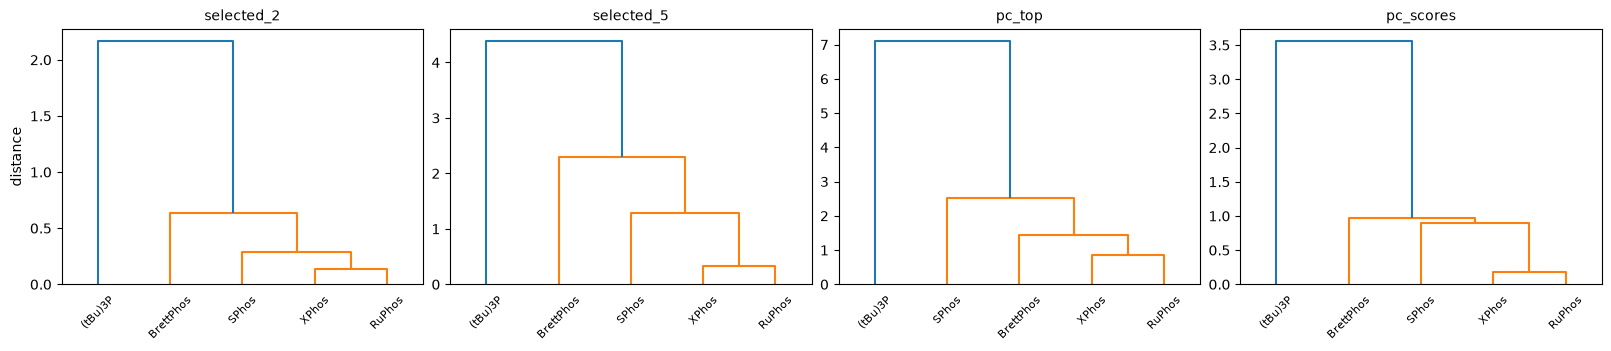

In [6]:
plt.close("all")
fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(4.0 * len(FEATURE_SETS), 3.4),
                         constrained_layout=True)
axl = np.atleast_1d(axes)
for ax, name in zip(axl, FEATURE_SETS):
    D = results[name]["euclidean"]
    Zl = linkage(squareform(D.values, checks=False), method="average")
    dendrogram(Zl, labels=list(D.index), ax=ax, leaf_font_size=8)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("distance" if ax is axl[0] else "")
    ax.tick_params(axis="x", rotation=45)
fig_dendro = fig
display(fig_dendro)
plt.close(fig_dendro)

## 2. How far is each from the Kraken population?

`leverage` above `h*` is the conventional flag for "outside the applicability domain".
`knn_percentile` is the most directly readable number: 90 means this catalyst sits in a
sparser neighbourhood than 90% of Kraken ligands.

In [7]:
ad = {}
for name, cols in FEATURE_SETS.items():
    table, h_star = population_distance(results[name]["Z"], results[name]["query"])
    ad[name] = table
    print(f"=== {name}   (M={len(cols)}, N={len(results[name]['Z'])}, h* = {h_star:.4f}) ===")
    print(table.round(3).to_string(), "\n")

=== selected_2   (M=2, N=1223, h* = 0.0074) ===
           leverage  outside_AD  mahalanobis  mahalanobis_robust  knn5_distance  knn_percentile
(tBu)3P       0.001       False        1.341               2.420          0.049          57.809
XPhos         0.007       False        3.000              12.021          0.065          68.520
SPhos         0.006       False        2.617              10.740          0.047          54.865
RuPhos        0.009        True        3.268              12.878          0.135          89.289
BrettPhos     0.007       False        2.933              11.979          0.163          92.723 

=== selected_5   (M=5, N=1223, h* = 0.0147) ===
           leverage  outside_AD  mahalanobis  mahalanobis_robust  knn5_distance  knn_percentile
(tBu)3P       0.005       False        2.358               2.955          0.465          55.846
XPhos         0.008       False        3.080              11.141          0.437          50.450
SPhos         0.008       False       

k-NN distance percentile within Kraken (higher = more unusual)
           selected_2  selected_5  pc_top  pc_scores
(tBu)3P          57.8        55.8    73.4       79.9
XPhos            68.5        50.4    55.1       35.5
SPhos            54.9        54.2    47.0        6.4
RuPhos           89.3        73.4    46.2       26.2
BrettPhos        92.7        81.8    61.9       45.5


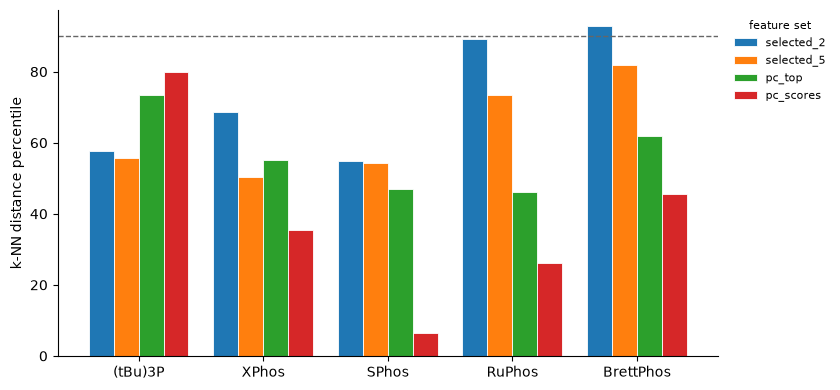

In [8]:
summary = pd.DataFrame({name: t["knn_percentile"] for name, t in ad.items()})
print("k-NN distance percentile within Kraken (higher = more unusual)")
print(summary.round(1).to_string())

plt.close("all")
ax = summary.plot.bar(figsize=(8.5, 4), width=0.8, edgecolor="white", linewidth=0.6)
ax.set(ylabel="k-NN distance percentile", xlabel="")
ax.axhline(90, color="0.4", linestyle="--", linewidth=1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="feature set", fontsize=8, title_fontsize=8, frameon=False,
          loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.spines[["top", "right"]].set_visible(False)
fig_ad = ax.figure
fig_ad.tight_layout()
display(fig_ad)
plt.close(fig_ad)

## 3. Where they sit inside Kraken

A 2-component PCA of each feature set, with the whole Kraken population in grey and the five
catalysts marked. This is for orientation only -- two components cannot show the full geometry
of a 12-dimensional set, and the percentages in the axis labels say how much is being lost.

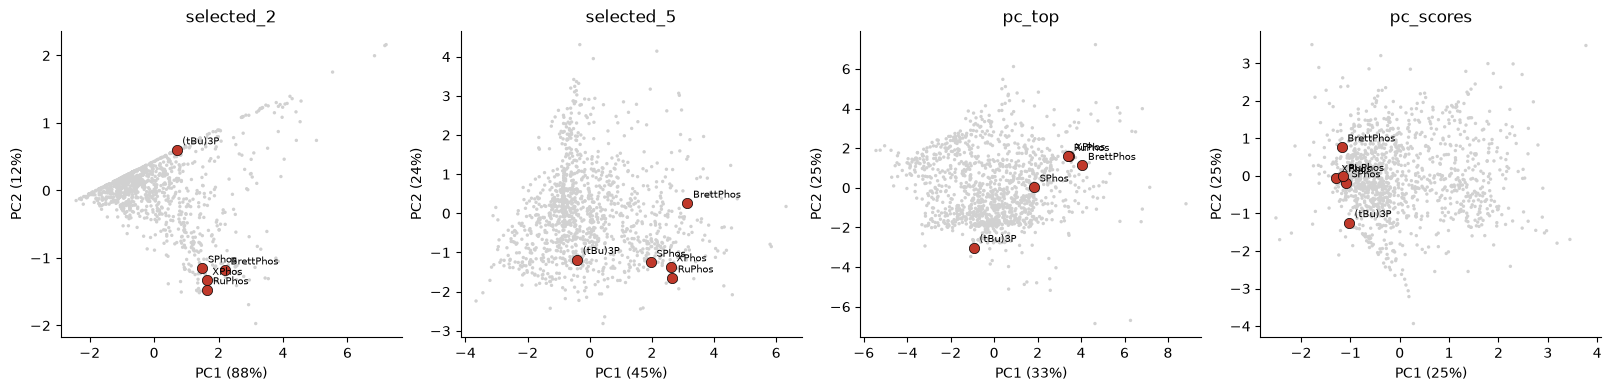

In [9]:
plt.close("all")
fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(4.0 * len(FEATURE_SETS), 3.8),
                         constrained_layout=True)
for ax, name in zip(np.atleast_1d(axes), FEATURE_SETS):
    Z, query = results[name]["Z"], results[name]["query"]
    pca = PCA(n_components=2).fit(Z.values)
    P, Q = pca.transform(Z.values), pca.transform(query.values)
    ax.scatter(P[:, 0], P[:, 1], s=6, c="0.82", edgecolors="none")
    ax.scatter(Q[:, 0], Q[:, 1], s=55, c="#c0392b", edgecolors="k", linewidths=0.5, zorder=3)
    for (x, y), lab in zip(Q, query.index):
        ax.annotate(lab, (x, y), fontsize=7, xytext=(4, 4), textcoords="offset points")
    v = pca.explained_variance_ratio_
    ax.set(title=name, xlabel=f"PC1 ({v[0]:.0%})", ylabel=f"PC2 ({v[1]:.0%})")
    ax.spines[["top", "right"]].set_visible(False)
fig_pca = fig
display(fig_pca)
plt.close(fig_pca)

## 4. Does the answer depend on the feature set?

If the five catalysts rank the same way in every feature set, the conclusion is robust. Where
they disagree, the feature set is doing the talking -- worth knowing before quoting any single
number.

In [10]:
rank = pd.DataFrame({name: t["knn_percentile"].rank(ascending=False).astype(int)
                     for name, t in ad.items()})
print("rank by k-NN percentile (1 = most unusual within Kraken)")
print(rank.to_string())
print("\nspread of ranks per catalyst (0 = every feature set agrees):")
print((rank.max(axis=1) - rank.min(axis=1)).to_string())

print("\ncorrelation of the pairwise-distance matrices between feature sets")
iu = np.triu_indices(len(CATALYSTS), 1)
flat = pd.DataFrame({n: results[n]["euclidean"].values[iu] for n in FEATURE_SETS})
print(flat.corr(method="spearman").round(3).to_string())

rank by k-NN percentile (1 = most unusual within Kraken)
           selected_2  selected_5  pc_top  pc_scores
(tBu)3P             4           3       1          1
XPhos               3           5       3          3
SPhos               5           4       4          5
RuPhos              2           2       5          4
BrettPhos           1           1       2          2

spread of ranks per catalyst (0 = every feature set agrees):
(tBu)3P      3
XPhos        2
SPhos        1
RuPhos       3
BrettPhos    1

correlation of the pairwise-distance matrices between feature sets
            selected_2  selected_5  pc_top  pc_scores
selected_2       1.000       1.000   0.782      0.939
selected_5       1.000       1.000   0.782      0.939
pc_top           0.782       0.782   1.000      0.855
pc_scores        0.939       0.939   0.855      1.000


## 5. The Kraken PC1 vs PC2 map

The PCA above was refitted *per feature set*, so its axes differ from panel to panel. This
section instead uses **Kraken's own principal components** -- the 4-component PCA fitted on
all 190 standardised descriptors across all 1,223 ligands, stored in `pca_reference` and
shipped precomputed as the `PC1..PC4` columns. These are the same axes every project uses for
the `pc_scores` feature set, and the same map the Kraken authors plot.

So this is one fixed chemical space, not a per-feature-set view: a ligand's position here does
not change with which descriptors a model happens to use.

Kraken reference PCA, explained variance: PC1 29.0%  PC2 13.0%  PC3 11.2%  PC4 6.1% | first two = 42.0%


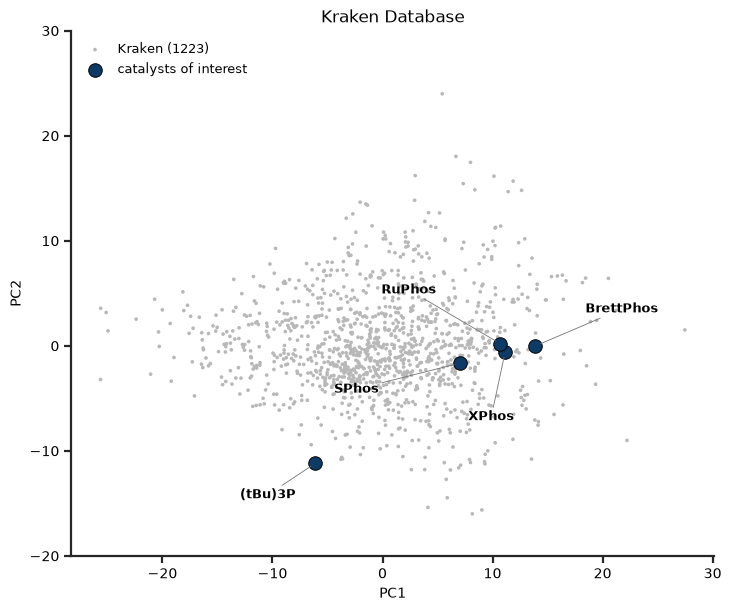


coordinates on the Kraken axes:
              PC1     PC2    PC3    PC4
(tBu)3P    -6.091 -11.179 -0.039  0.100
XPhos      11.147  -0.575  7.390 -4.352
SPhos       7.007  -1.658  4.497 -3.397
RuPhos     10.699   0.204  7.171 -4.242
BrettPhos  13.894  -0.018  4.626 -2.207


In [11]:
# PC1..PC4 are precomputed in ligand_features.csv and are exactly
# (standardise -> centre -> project onto reference.components), verified elsewhere.
PCS = ligands.set_index("kraken_id")[["PC1", "PC2", "PC3", "PC4"]]
var = np.asarray(reference.variance_ratio)
# Printed rather than put in the axis labels, so the map stays clean but the
# number is still on the page.
print("Kraken reference PCA, explained variance:",
      "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(var)),
      f"| first two = {var[:2].sum():.1%}")

# ---- shared look for both Kraken maps (this one and the per-benchmark one) ----
KRAKEN_GREY = "0.72"
CATALYST_BLUE = "#0d3b66"
PC_YLIM = (-20, 30)


def thicken_axes(ax, width=1.6):
    ax.spines[["top", "right"]].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(width)
        ax.spines[side].set_color("0.15")
    ax.tick_params(width=width, length=5, labelsize=10, color="0.15")


def place_label(ax, xy, text, offset, fontsize=9, weight="bold"):
    """Label at a hand-set offset, with a leader line back to its marker.

    XPhos, RuPhos and BrettPhos sit within ~3 PC1 units of each other, which is
    a couple of millimetres on this map -- closer than the labels are wide. No
    uniform offset can separate them, so each is placed by hand and the leader
    line is what keeps it attached to the right marker.
    """
    dx, dy = offset
    ax.annotate(text, xy, xytext=offset, textcoords="offset points",
                fontsize=fontsize, fontweight=weight,
                ha="center" if abs(dx) < 12 else ("left" if dx > 0 else "right"),
                va="bottom" if dy > 0 else "top",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45",
                                shrinkA=0, shrinkB=4))


CATALYST_LABEL_OFFSETS = {          # points from the marker; tuned against the render
    "(tBu)3P": (-14, -18),
    "SPhos": (-58, -14),
    "XPhos": (-10, -42),
    "RuPhos": (-46, 34),
    "BrettPhos": (36, 22),
}

plt.close("all")
fig, ax = plt.subplots(figsize=(7.2, 6.0), constrained_layout=True)
ax.scatter(PCS.PC1, PCS.PC2, s=7, c=KRAKEN_GREY, edgecolors="none",
           label=f"Kraken ({len(PCS)})")

q = PCS.loc[list(CATALYSTS.values())]
ax.scatter(q.PC1, q.PC2, s=95, c=CATALYST_BLUE, edgecolors="k", linewidths=0.7, zorder=3,
           label="catalysts of interest")
for (kid, row), lab in zip(q.iterrows(), CATALYSTS):
    place_label(ax, (row.PC1, row.PC2), lab, CATALYST_LABEL_OFFSETS[lab])

ax.set(xlabel="PC1", ylabel="PC2", ylim=PC_YLIM, title="Kraken Database")
ax.legend(frameon=False, fontsize=9, loc="upper left")
thicken_axes(ax)
fig_kraken_pca = fig
display(fig_kraken_pca)
plt.close(fig_kraken_pca)

print()
print("coordinates on the Kraken axes:")
coords = q.copy(); coords.index = list(CATALYSTS)
print(coords.round(3).to_string())

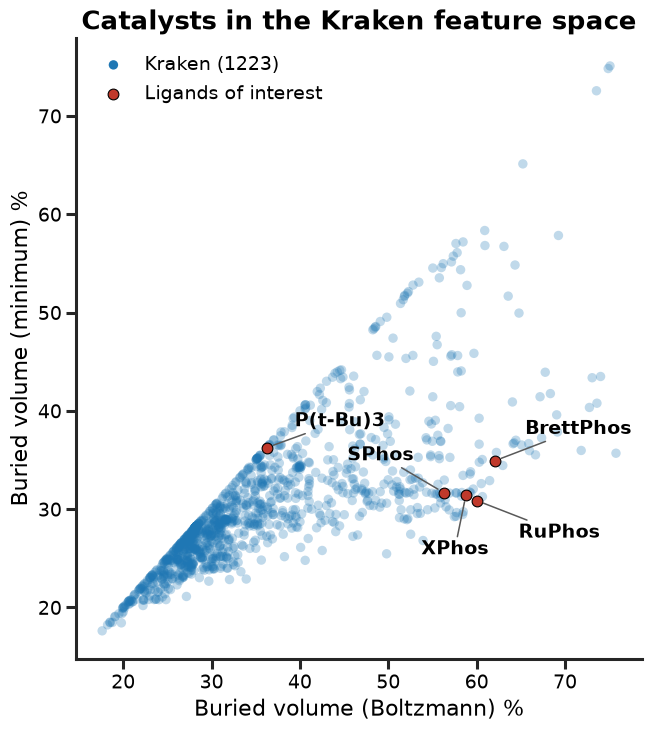

           vbur_pct_boltz  vbur_pct_min
(tBu)3P            36.264        36.264
XPhos              58.780        31.436
SPhos              56.290        31.668
RuPhos             60.029        30.863
BrettPhos          62.031        34.911


In [27]:
# ---------------- Editable ----------------
TITLE  = "Catalysts in the Kraken feature space"
XLABEL = "Buried volume (Boltzmann) %"
YLABEL = "Buried volume (minimum) %"

KRAKEN_LEGEND   = "Kraken"
CATALYST_LEGEND = "Ligands of interest"

CATALYST_LABELS = {
    "(tBu)3P":   "P(t-Bu)3",
    "XPhos":     "XPhos",
    "SPhos":     "SPhos",
    "RuPhos":    "RuPhos",
    "BrettPhos": "BrettPhos",
}

FIG_WIDTH, FIG_HEIGHT = 6.4, 7.2      # inches

FS_TITLE, FS_AXIS, FS_TICK, FS_LEGEND, FS_MARKER = 19, 16, 14, 14, 14

KRAKEN_BLUE   = "#1f77b4"
KRAKEN_ALPHA  = 0.28     # overlap darkens, so dense regions read as heavier
KRAKEN_SIZE   = 46
CATALYST_RED  = "#c0392b"
CATALYST_SIZE = 60       # set equal to KRAKEN_SIZE for an exact match
# ------------------------------------------

STANDARDISE = False      # True -> Kraken z-units (update the labels above to match)
SHOW_KRAKEN = True

LABEL_OFFSETS = {        # points, keyed by the CATALYSTS name, not the display name
    "(tBu)3P": (20, 12), "SPhos": (-22, 20), "XPhos": (-8, -32),
    "RuPhos": (30, -16), "BrettPhos": (22, 16),
}

xcol, ycol = FEATURE_SETS["selected_2"]

if STANDARDISE:
    pop, pts = standardised([xcol, ycol])
else:
    pop = ligands.set_index("kraken_id")[[xcol, ycol]].apply(pd.to_numeric, errors="coerce")
    pts = pop.loc[list(CATALYSTS.values())].copy()
    pts.index = list(CATALYSTS)

plt.close("all")
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)

if SHOW_KRAKEN:
    ax.scatter(pop[xcol], pop[ycol], s=KRAKEN_SIZE, c=KRAKEN_BLUE,
               alpha=KRAKEN_ALPHA, edgecolors="none",
               label=f"{KRAKEN_LEGEND} ({len(pop)})")
ax.scatter(pts[xcol], pts[ycol], s=CATALYST_SIZE, c=CATALYST_RED, edgecolors="k",
           linewidths=0.8, zorder=3, label=CATALYST_LEGEND)

for name, row in pts.iterrows():
    dx, dy = LABEL_OFFSETS.get(name, (20, 12))
    ax.annotate(CATALYST_LABELS.get(name, name), (row[xcol], row[ycol]),
                xytext=(dx, dy), textcoords="offset points",
                fontsize=FS_MARKER, fontweight="bold", zorder=4,
                ha="center" if abs(dx) < 14 else ("left" if dx > 0 else "right"),
                va="bottom" if dy > 0 else "top",
                arrowprops=dict(arrowstyle="-", lw=1.1, color="0.35",
                                shrinkA=0, shrinkB=5))

ax.set_xlabel(XLABEL, fontsize=FS_AXIS)
ax.set_ylabel(YLABEL, fontsize=FS_AXIS)
ax.set_title(TITLE, fontsize=FS_TITLE, fontweight="bold")
leg = ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left", handletextpad=0.6)
for handle in leg.legend_handles:
    handle.set_alpha(1.0)          # legend dot solid even though the cloud is not
ax.spines[["top", "right"]].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_linewidth(2.2)
    ax.spines[side].set_color("0.15")
ax.tick_params(width=2.2, length=7, labelsize=FS_TICK, color="0.15")

fig_selected_2 = fig
display(fig_selected_2)
plt.close(fig_selected_2)

print(pts.round(3).to_string())


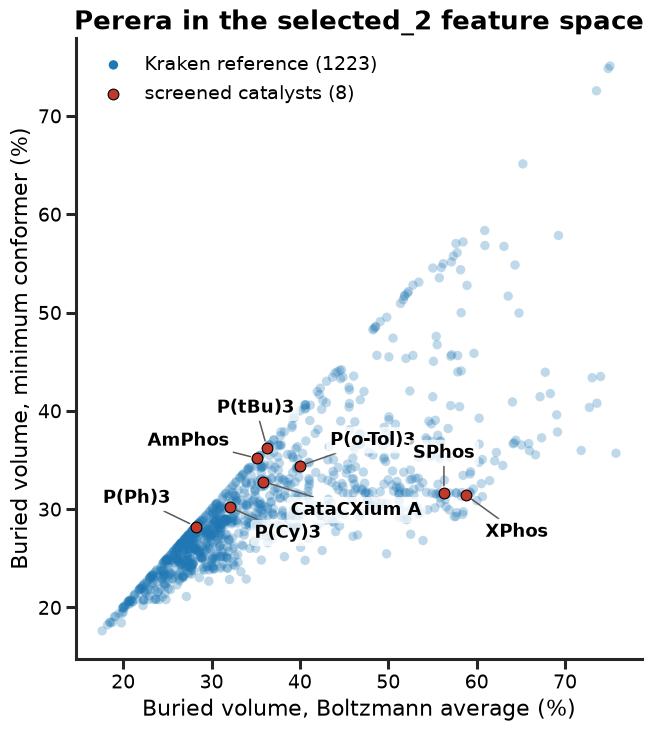

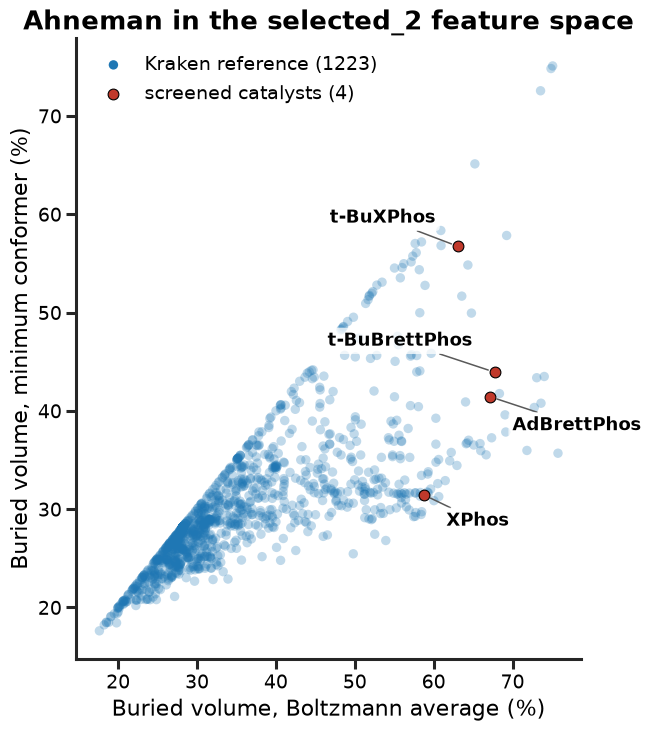

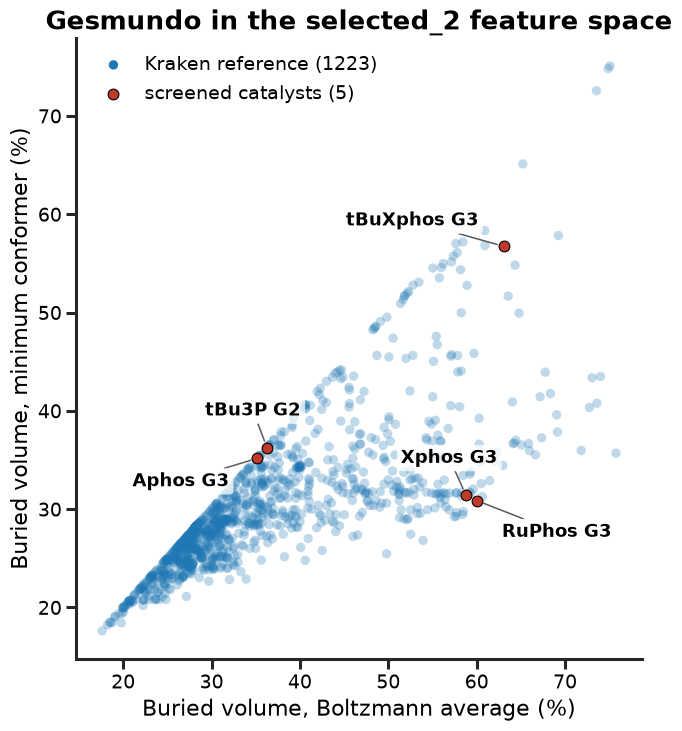

In [26]:
# ---------------- Editable ----------------
TITLE_TEMPLATE = "{dataset} in the selected_2 feature space"
XLABEL = "Buried volume, Boltzmann average (%)"
YLABEL = "Buried volume, minimum conformer (%)"

KRAKEN_LEGEND   = "Kraken reference"
CATALYST_LEGEND = "screened catalysts"

DATASET_TITLES = {          # what {dataset} becomes in the title
    "Perera (Suzuki, 8)": "Perera",
    "Ahneman BH (4)":     "Ahneman",
    "Gesmundo (5)":       "Gesmundo",
}

CATALYST_LABELS = {}        # rename any marker label, e.g. {"P(tBu)3": "P(t-Bu)3"}

FIG_WIDTH, FIG_HEIGHT = 6.4, 7.2      # inches
FS_TITLE, FS_AXIS, FS_TICK, FS_LEGEND, FS_MARKER = 19, 16, 14, 14, 13

KRAKEN_BLUE   = "#1f77b4"
KRAKEN_ALPHA  = 0.28     # overlap darkens, so dense regions read as heavier
KRAKEN_SIZE   = 46
CATALYST_RED  = "#c0392b"
CATALYST_SIZE = 60
LABEL_BOX_ALPHA = 0.75   # white backing behind each label; 0 for none
# ------------------------------------------

STANDARDISE = False      # True -> Kraken z-units (update the labels above to match)
SHOW_KRAKEN = True

# Per dataset, because the same ligand needs a different direction depending on
# what else is near it: XPhos is alone on the right in Ahneman but sits next to
# SPhos in Perera.
LABEL_OFFSETS = {
    "Perera (Suzuki, 8)": {
        "P(Ph)3": (-18, 14), "P(Cy)3": (18, -12), "AmPhos": (-20, 6),
        "P(tBu)3": (-8, 22), "CataCXium A": (20, -14), "P(o-Tol)3": (22, 12),
        "SPhos": (0, 22), "XPhos": (14, -20),
    },
    "Ahneman BH (4)": {
        "XPhos": (16, -12), "t-BuXPhos": (-16, 14),
        "AdBrettPhos": (16, -14), "t-BuBrettPhos": (-16, 16),
    },
    "Gesmundo (5)": {
        "Aphos G3": (-20, -10), "tBu3P G2": (-10, 20),
        "Xphos G3": (-12, 20), "RuPhos G3": (18, -16), "tBuXphos G3": (-18, 12),
    },
}

xcol, ycol = FEATURE_SETS["selected_2"]

if STANDARDISE:
    pop, _ = standardised([xcol, ycol])
else:
    pop = ligands.set_index("kraken_id")[[xcol, ycol]].apply(pd.to_numeric, errors="coerce")

plt.close("all")
figs_selected_2 = {}

for label, mapping in DATASETS.items():
    pts = pop.loc[list(mapping.values())].copy()
    pts.index = list(mapping)
    offsets = LABEL_OFFSETS.get(label, {})

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)

    if SHOW_KRAKEN:
        ax.scatter(pop[xcol], pop[ycol], s=KRAKEN_SIZE, c=KRAKEN_BLUE,
                   alpha=KRAKEN_ALPHA, edgecolors="none",
                   label=f"{KRAKEN_LEGEND} ({len(pop)})")
    ax.scatter(pts[xcol], pts[ycol], s=CATALYST_SIZE, c=CATALYST_RED, edgecolors="k",
               linewidths=0.8, zorder=3, label=f"{CATALYST_LEGEND} ({len(pts)})")

    for name, row in pts.iterrows():
        dx, dy = offsets.get(name, (18, 12))
        ax.annotate(CATALYST_LABELS.get(name, name), (row[xcol], row[ycol]),
                    xytext=(dx, dy), textcoords="offset points",
                    fontsize=FS_MARKER, fontweight="bold", zorder=4,
                    ha="center" if abs(dx) < 14 else ("left" if dx > 0 else "right"),
                    va="bottom" if dy > 0 else "top",
                    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none",
                              alpha=LABEL_BOX_ALPHA),
                    arrowprops=dict(arrowstyle="-", lw=1.1, color="0.35",
                                    shrinkA=0, shrinkB=5))

    ax.set_xlabel(XLABEL, fontsize=FS_AXIS)
    ax.set_ylabel(YLABEL, fontsize=FS_AXIS)
    ax.set_title(TITLE_TEMPLATE.format(dataset=DATASET_TITLES.get(label, label)),
                 fontsize=FS_TITLE, fontweight="bold")
    leg = ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left", handletextpad=0.6)
    for handle in leg.legend_handles:
        handle.set_alpha(1.0)          # legend dot solid even though the cloud is not
    ax.spines[["top", "right"]].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(2.2)
        ax.spines[side].set_color("0.15")
    ax.tick_params(width=2.2, length=7, labelsize=FS_TICK, color="0.15")

    figs_selected_2[label] = fig
    display(fig)
    plt.close(fig)


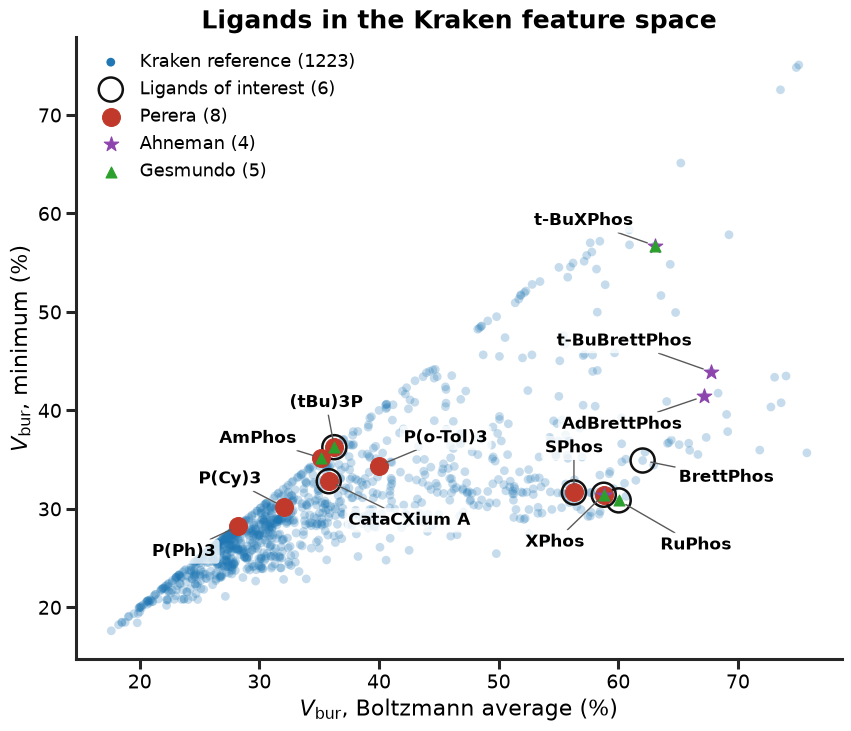

13 distinct ligands across 4 series


In [33]:
# CataCXium A (kraken_id 10) joins the interest set for this figure only. To make
# it one everywhere -- distance tables, the Kraken maps -- add it to CATALYSTS in
# the cell near the top instead.
INTEREST = {**CATALYSTS, "CataCXium A": 10}

# ---------------- Editable ----------------
TITLE  = "Ligands in the Kraken feature space"
# r"" strings so the mathtext backslash survives; the % sits outside the $...$
# because inside mathtext it would start a TeX comment.
XLABEL = r"$V_\mathrm{bur}$, Boltzmann average (%)"
YLABEL = r"$V_\mathrm{bur}$, minimum (%)"

KRAKEN_LEGEND = "Kraken reference"
SHOW_COUNTS   = True     # False -> legend names only, no "(n)"

# (legend name, source dict, colour, marker, size). Drawn first to last, so the
# first entry ends up underneath: sizes descend for that reason, and a ligand
# used by several screens shows as nested markers rather than one hiding another.
SERIES = [
    ("Ligands of interest",   INTEREST,                       "#111111", "o", 300),
    ("Perera",                DATASETS["Perera (Suzuki, 8)"], "#c0392b", "o", 165),
    ("Ahneman",               DATASETS["Ahneman BH (4)"],     "#8e44ad", "*", 120),
    ("Gesmundo",              DATASETS["Gesmundo (5)"],       "#2ca02c", "^", 62),
]
INTEREST_IS_RING = True   # draw the first series as an open ring, not a filled dot

FIG_WIDTH, FIG_HEIGHT = 8.4, 7.2
FS_TITLE, FS_AXIS, FS_TICK, FS_LEGEND, FS_MARKER = 18, 16, 14, 13, 12

KRAKEN_BLUE  = "#1f77b4"
KRAKEN_ALPHA = 0.25
KRAKEN_SIZE  = 40
LABEL_BOX_ALPHA = 0.78
SHOW_LABELS = True
# ------------------------------------------

STANDARDISE = False      # True -> Kraken z-units (update the labels above to match)
SHOW_KRAKEN = True

# One label per ligand, under the name the first series to claim it uses.
LABEL_OFFSETS = {
    "(tBu)3P": (-6, 26), "SPhos": (0, 26), "XPhos": (-14, -28),
    "RuPhos": (30, -26), "BrettPhos": (26, -6),
    "AmPhos": (-18, 8), "CataCXium A": (14, -22), "P(Cy)3": (-16, 14),
    "P(Ph)3": (-16, -12), "P(o-Tol)3": (18, 14),
    "AdBrettPhos": (-16, -14), "t-BuBrettPhos": (-14, 16), "t-BuXPhos": (-16, 12),
}

xcol, ycol = FEATURE_SETS["selected_2"]

if STANDARDISE:
    pop, _ = standardised([xcol, ycol])
else:
    pop = ligands.set_index("kraken_id")[[xcol, ycol]].apply(pd.to_numeric, errors="coerce")

plt.close("all")
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), constrained_layout=True)

if SHOW_KRAKEN:
    name = f"{KRAKEN_LEGEND} ({len(pop)})" if SHOW_COUNTS else KRAKEN_LEGEND
    ax.scatter(pop[xcol], pop[ycol], s=KRAKEN_SIZE, c=KRAKEN_BLUE,
               alpha=KRAKEN_ALPHA, edgecolors="none", label=name)

seen = {}
for z, (name, mapping, colour, marker, size) in enumerate(SERIES, start=3):
    pts = pop.loc[list(mapping.values())]
    legend_name = f"{name} ({len(mapping)})" if SHOW_COUNTS else name
    ring = INTEREST_IS_RING and z == 3
    ax.scatter(pts[xcol], pts[ycol], s=size, marker=marker, zorder=z,
               facecolors="none" if ring else colour,
               edgecolors=colour, linewidths=1.8 if ring else 0.8,
               label=legend_name)
    for label_name, kid in mapping.items():
        seen.setdefault(kid, label_name)

if SHOW_LABELS:
    for kid, label_name in seen.items():
        row = pop.loc[kid]
        dx, dy = LABEL_OFFSETS.get(label_name, (16, 12))
        ax.annotate(label_name, (row[xcol], row[ycol]), xytext=(dx, dy),
                    textcoords="offset points", fontsize=FS_MARKER,
                    fontweight="bold", zorder=10,
                    ha="center" if abs(dx) < 14 else ("left" if dx > 0 else "right"),
                    va="bottom" if dy > 0 else "top",
                    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="none",
                              alpha=LABEL_BOX_ALPHA),
                    arrowprops=dict(arrowstyle="-", lw=1.0, color="0.35",
                                    shrinkA=0, shrinkB=6))

ax.set_xlabel(XLABEL, fontsize=FS_AXIS)
ax.set_ylabel(YLABEL, fontsize=FS_AXIS)
ax.set_title(TITLE, fontsize=FS_TITLE, fontweight="bold")
leg = ax.legend(frameon=False, fontsize=FS_LEGEND, loc="upper left", handletextpad=0.6)
for handle in leg.legend_handles:
    handle.set_alpha(1.0)
ax.spines[["top", "right"]].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_linewidth(2.2)
    ax.spines[side].set_color("0.15")
ax.tick_params(width=2.2, length=7, labelsize=FS_TICK, color="0.15")

fig_all_catalysts = fig
display(fig_all_catalysts)
plt.close(fig_all_catalysts)

print(f"{len(seen)} distinct ligands across {len(SERIES)} series")


In [1]:
uv pip install --python "C:\venvs\gp-collab-hazel\Scripts\python.exe" rdkit


Note: you may need to restart the kernel to use updated packages.


c:\venvs\gp-collab-hazel\Scripts\python.exe: No module named uv


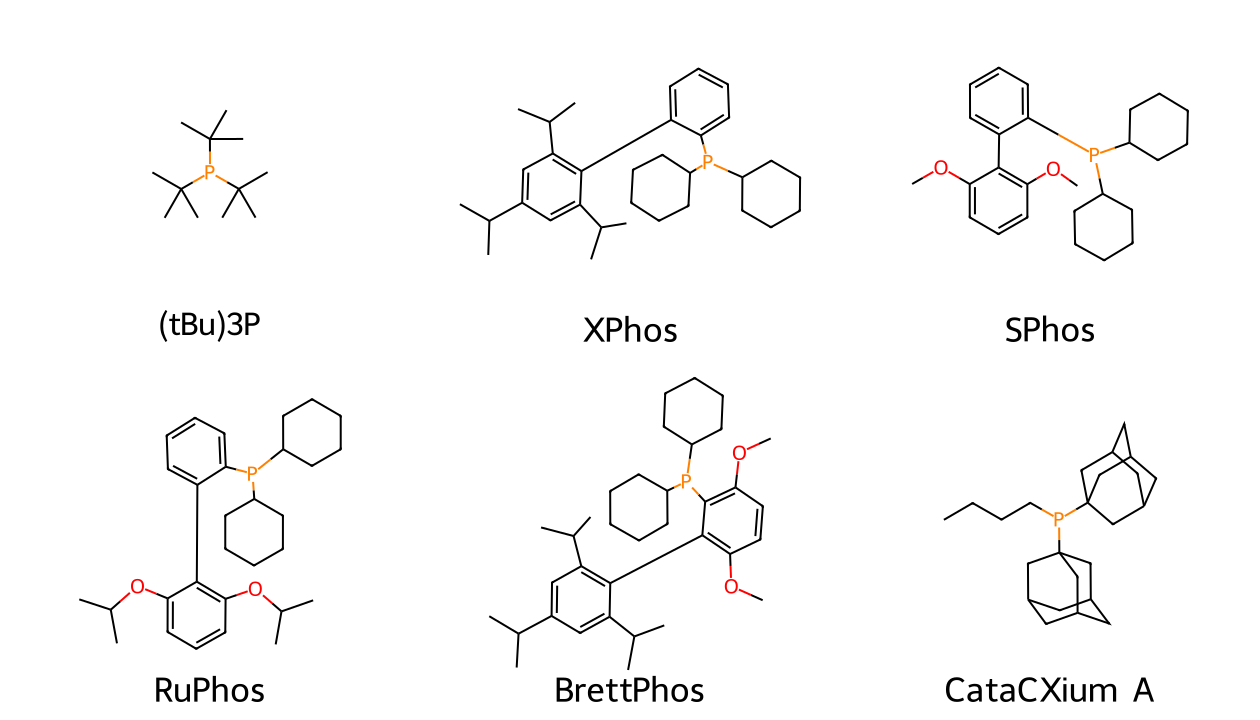

6 structures, 3 per row, 2 rows  |  SMILES from kraken_identifiers.csv


In [2]:
# Structures of the six ligands of interest, 3 per row.
# Needs RDKit:  pip install rdkit
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

# ---------------- Editable ----------------
# name shown under the structure -> kraken_id
LIGANDS = {
    "(tBu)3P":     8,
    "XPhos":       1,
    "SPhos":       3,
    "RuPhos":      4,
    "BrettPhos":   102,
    "CataCXium A": 10,
}
PER_ROW    = 3
PANEL_W, PANEL_H = 420, 360      # pixels per structure
LEGEND_FONT = 34
BOND_WIDTH  = 2
SAVE_TO     = None               # e.g. "ligands_of_interest.png"
# ------------------------------------------

# SMILES live in the raw rxnpredict bundle, not in the prepared inputs, so the
# file is looked up rather than assumed. can_smiles is the canonical column the
# notebook's id checks were made against.
CANDIDATES = [
    Path.cwd() / "gp_collab_hazel/prep_rxnpredict/raw_rxnpredict/kraken_identifiers.csv",
    Path.cwd() / "gp_collab_rxnpredict/prep_rxnpredict/raw_rxnpredict/kraken_identifiers.csv",
]
ids_path = next((p for p in CANDIDATES if p.exists()), None)
if ids_path is None:
    raise FileNotFoundError(f"kraken_identifiers.csv not found; looked in {CANDIDATES}")

ids = pd.read_csv(ids_path)
ids["id"] = pd.to_numeric(ids["id"], errors="coerce")
ids = ids.dropna(subset=["id"])
smiles_by_id = dict(zip(ids["id"].astype(int), ids["can_smiles"]))

rdDepictor.SetPreferCoordGen(True)      # cleaner ring/biaryl layouts

mols, legends = [], []
for name, kid in LIGANDS.items():
    smi = smiles_by_id.get(kid)
    if smi is None:
        raise KeyError(f"{name}: kraken_id {kid} not in {ids_path.name}")
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        raise ValueError(f"{name}: RDKit could not parse {smi!r}")
    rdDepictor.Compute2DCoords(mol)
    mols.append(mol)
    legends.append(name)

rows = -(-len(mols) // PER_ROW)         # ceiling division
drawer = rdMolDraw2D.MolDraw2DCairo(PANEL_W * PER_ROW, PANEL_H * rows, PANEL_W, PANEL_H)
opts = drawer.drawOptions()
opts.legendFontSize = LEGEND_FONT
opts.bondLineWidth = BOND_WIDTH
drawer.DrawMolecules(mols, legends=legends)
drawer.FinishDrawing()
png = drawer.GetDrawingText()

if SAVE_TO:
    Path(SAVE_TO).write_bytes(png)
    print("saved:", SAVE_TO)

display(Image(png))
print(f"{len(mols)} structures, {PER_ROW} per row, {rows} rows  |  SMILES from {ids_path.name}")


In [31]:
# ---------------- Editable ----------------
SPACE        = "selected_2"
STANDARDISE  = True
METRIC       = "euclidean"
SHOW_KRAKEN_ROW = True      # the whole population as a reference row
GROUPS = {"catalysts of interest": CATALYSTS, **DATASETS}
# ------------------------------------------

cols = FEATURE_SETS[SPACE]
if STANDARDISE:
    Z, _ = standardised(cols)
    unit = "Kraken SD"
else:
    Z = ligands.set_index("kraken_id")[cols].apply(pd.to_numeric, errors="coerce")
    unit = "raw units"

blocks = {label: Z.loc[list(m.values())] for label, m in GROUPS.items()}
if SHOW_KRAKEN_ROW:
    blocks[f"Kraken (all {len(Z)})"] = Z

rows, per_descriptor = [], {}
for label, P in blocks.items():
    D = pairwise_distances(P.values, metric=METRIC)
    pairs = D[np.triu_indices_from(D, 1)]

    # Distance of each member from the group's own centre: the radius of the
    # cloud, as opposed to the separation between its members.
    radius = np.linalg.norm(P.values - P.values.mean(axis=0), axis=1)

    rows.append({"group": label, "n": len(P), "n_pairs": len(pairs),
                 "dist_mean": pairs.mean(), "dist_sd": pairs.std(ddof=1),
                 "dist_min": pairs.min(), "dist_max": pairs.max(),
                 "radius_mean": radius.mean(), "radius_sd": radius.std(ddof=1)})
    per_descriptor[label] = P.std(ddof=1)

table = pd.DataFrame(rows).set_index("group")
print(f"{SPACE} | {METRIC} distance, {unit}\n")
print(table.round(2).to_string(), "\n")

print(f"mean +/- SD of the pairwise distances ({unit}):")
for label, r in table.iterrows():
    print(f"    {label:<24} {r.dist_mean:5.2f} +/- {r.dist_sd:.2f}   (n = {int(r.n)})")

print(f"\nper-descriptor SD within each group ({unit}):")
print(pd.DataFrame(per_descriptor).T.round(2).to_string())


selected_2 | euclidean distance, Kraken SD

                          n  n_pairs  dist_mean  dist_sd  dist_min  dist_max  radius_mean  radius_sd
group                                                                                               
catalysts of interest     5       10       1.13     0.92      0.14      2.33         0.74       0.58
Perera (Suzuki, 8)        8       28       1.31     0.81      0.19      2.79         0.89       0.51
Ahneman BH (4)            4        6       1.99     1.08      0.37      3.73         1.13       0.89
Gesmundo (5)              5       10       2.47     1.44      0.14      4.04         1.66       0.73
Kraken (all 1223)      1223   747253       1.56     1.26      0.00      9.89         1.13       0.86 

mean +/- SD of the pairwise distances (Kraken SD):
    catalysts of interest     1.13 +/- 0.92   (n = 5)
    Perera (Suzuki, 8)        1.31 +/- 0.81   (n = 8)
    Ahneman BH (4)            1.99 +/- 1.08   (n = 4)
    Gesmundo (5)              2.47

### What the axes mean

From the loadings, the four reference components separate into interpretable blocks -- bulk
size, local geometry at phosphorus, conformational flexibility, and electronics at phosphorus.
The three highest-|loading| descriptors on PC1 and PC2 are printed below so the map can be
read chemically rather than just geometrically.

In [12]:
C = np.asarray(reference.components)
cols = list(reference.columns)
for k in (0, 1):
    order = np.argsort(-np.abs(C[k]))[:6]
    print(f"PC{k+1} ({var[k]:.1%}) top loadings:")
    for j in order:
        print(f"    {C[k, j]:+.3f}  {cols[j]}")
    print()

PC1 (29.0%) top loadings:
    +0.124  vbur_vtot_boltz
    +0.124  volume_boltz
    +0.123  vbur_near_vtot_vburminconf
    +0.123  vbur_near_vtot_max
    +0.122  surface_area_boltz
    +0.119  Pint_P_max_boltz

PC2 (13.0%) top loadings:
    +0.130  pyr_P_max
    +0.129  qpole_amp_max
    -0.129  vbur_qvbur_min_min
    -0.129  pyr_alpha_min
    -0.128  qpoletens_zz_min
    +0.128  qpoletens_xx_max



## 6. Distance heat maps for the catalysts in each dataset

The five above are a hand-picked set. This section instead takes the catalysts **actually
screened in each benchmark** and shows how far apart they are, in every feature set.
Datasets are named by first author.

| dataset | group column | catalysts |
|---|---|---|
| Perera 2018 (Suzuki) | `ligand` | 8 |
| Ahneman 2018 (Buchwald-Hartwig) | `ligand` | 4 |
| Gesmundo (Suzuki informer) | `catalyst` | 5 |

Reading these: the numbers are euclidean distances in standardised Kraken units, so a value of
1.0 means the two ligands differ by about one Kraken standard deviation, averaged in
quadrature over that feature set's descriptors. Every panel shares one colour scale, so a
block is directly comparable across datasets *and* across feature sets: dark means chemically
similar, bright means far apart. Note that a feature set with more descriptors spreads
everything out -- distance grows with dimension -- so `pc_top` (12 descriptors) runs brighter
than `selected_2` (2) throughout, and that is the axis, not the chemistry.

In [13]:
# Named by first author: Ahneman 2018 (the Doyle Buchwald-Hartwig screen) and
# Gesmundo (the Cernak Suzuki informer library).
DATASETS = {
    "Perera (Suzuki, 8)": {
        "AmPhos": 216, "CataCXium A": 10, "P(Cy)3": 11, "P(Ph)3": 17,
        "P(o-Tol)3": 9, "P(tBu)3": 8, "SPhos": 3, "XPhos": 1,
    },
    "Ahneman BH (4)": {
        "AdBrettPhos": 347, "XPhos": 1, "t-BuBrettPhos": 89, "t-BuXPhos": 90,
    },
    "Gesmundo (5)": {
        "Aphos G3": 216, "RuPhos G3": 4, "Xphos G3": 1,
        "tBu3P G2": 8, "tBuXphos G3": 90,
    },
}

for label, mapping in DATASETS.items():
    absent = [n for n, i in mapping.items() if i not in set(ligands.kraken_id)]
    assert not absent, f"{label}: not in Kraken -> {absent}"
print("every dataset catalyst resolves in the Kraken table")


def dataset_distances(mapping, cols, metric="euclidean"):
    """Pairwise distances for one dataset's catalysts, standardised on all of Kraken."""
    Z, _ = standardised(cols)
    sub = Z.loc[list(mapping.values())].copy()
    sub.index = list(mapping)
    return pd.DataFrame(pairwise_distances(sub.values, metric=metric),
                        index=sub.index, columns=sub.index)

every dataset catalyst resolves in the Kraken table


shared colour scale: 0.00 to 7.75 standardised Kraken units


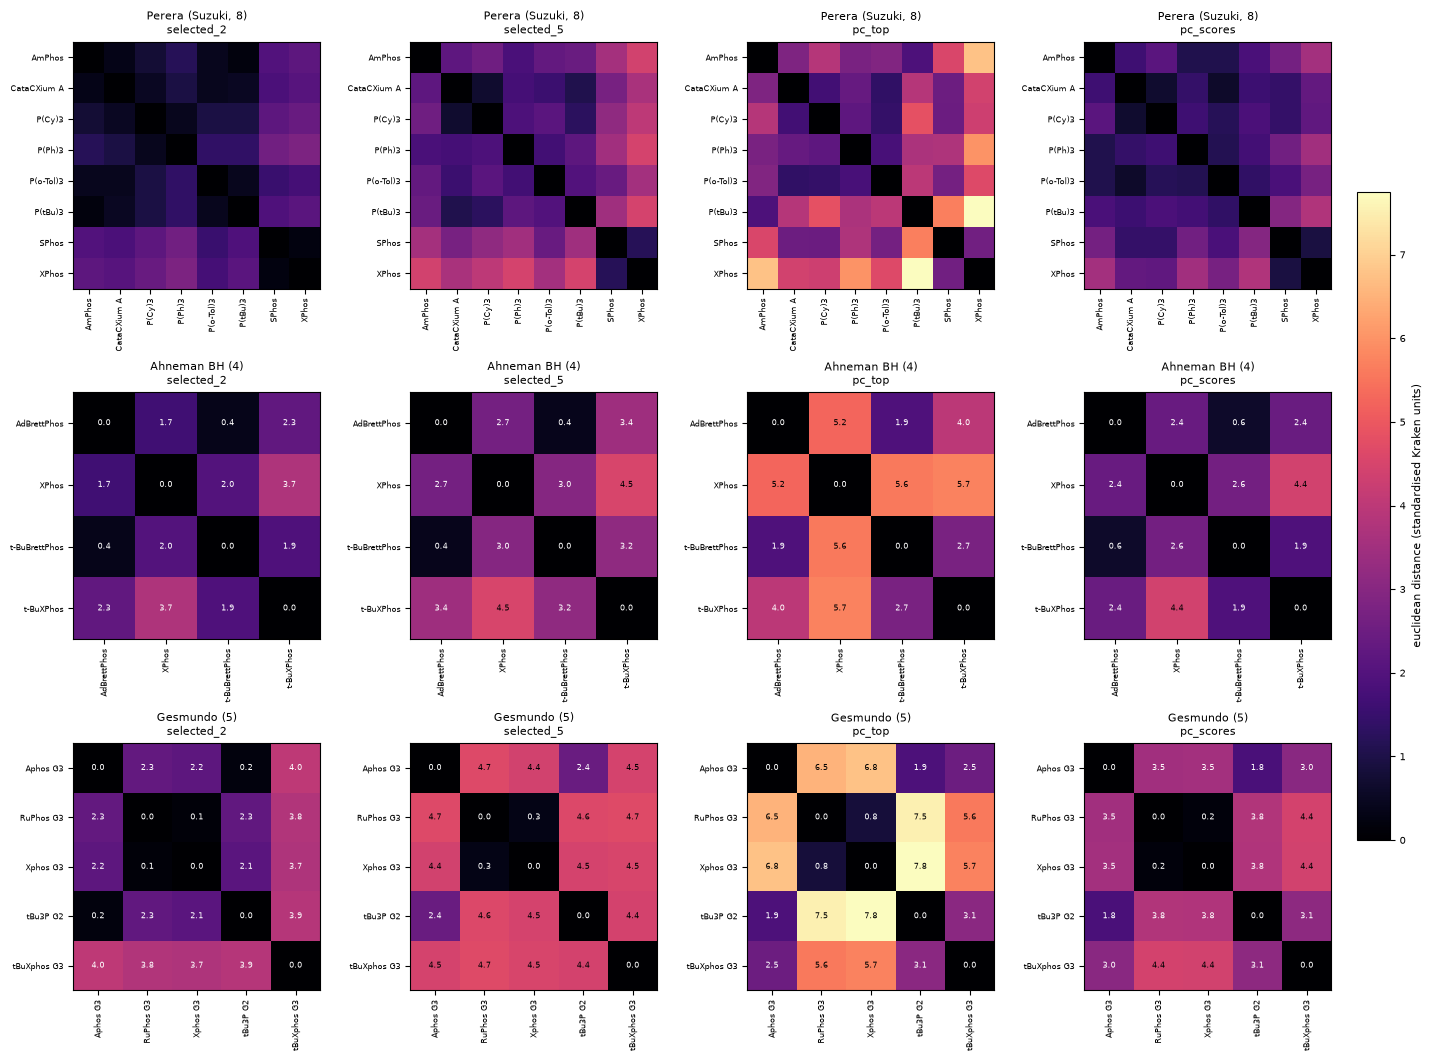

In [14]:
# Every matrix is built first, so one colour scale can cover all of them: with a
# per-panel scale each heat map normalises to its own maximum and a dark block in
# one panel means nothing about a dark block in the next. Shared vmin/vmax makes
# the twelve panels one figure rather than twelve unrelated ones.
dataset_D = {}
for label, mapping in DATASETS.items():
    dataset_D[label] = {fname: dataset_distances(mapping, cols)
                        for fname, cols in FEATURE_SETS.items()}

VMIN = 0.0
VMAX = max(D.values.max() for per_set in dataset_D.values() for D in per_set.values())
print(f"shared colour scale: {VMIN:.2f} to {VMAX:.2f} standardised Kraken units")

plt.close("all")
nrow, ncol = len(DATASETS), len(FEATURE_SETS)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.5 * nrow),
                         constrained_layout=True)

for i, label in enumerate(DATASETS):
    for j, fname in enumerate(FEATURE_SETS):
        D = dataset_D[label][fname]
        ax = axes[i, j]
        im = ax.imshow(D.values, cmap="magma", vmin=VMIN, vmax=VMAX)
        ax.set_xticks(range(len(D)), D.columns, rotation=90, fontsize=6)
        ax.set_yticks(range(len(D)), D.index, fontsize=6)
        if len(D) <= 6:
            # Threshold on the shared scale, not this panel's own range, so the
            # same number is the same colour in every panel.
            hi = VMAX * 0.55
            for a in range(len(D)):
                for b in range(len(D)):
                    ax.text(b, a, f"{D.values[a, b]:.1f}", ha="center", va="center",
                            fontsize=5.5,
                            color="w" if D.values[a, b] < hi else "k")
        ax.set_title(f"{label}\n{fname}", fontsize=8)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
cbar.set_label("euclidean distance (standardised Kraken units)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig_dataset_heat = fig
display(fig_dataset_heat)
plt.close(fig_dataset_heat)

In [15]:
# How much of the space does each screen actually span?
rows = []
for label, per_set in dataset_D.items():
    for fname, D in per_set.items():
        iu = np.triu_indices_from(D.values, 1)
        d = D.values[iu]
        rows.append({"dataset": label, "feature_set": fname, "n_catalysts": len(D),
                     "mean_pairwise": d.mean(), "min_pairwise": d.min(),
                     "max_pairwise": d.max()})
spread = pd.DataFrame(rows)
print("pairwise distance spread, standardised Kraken units")
print(spread.pivot(index="dataset", columns="feature_set", values="mean_pairwise").round(2).to_string())
print()
for label, per_set in dataset_D.items():
    D = per_set["selected_5"]
    iu = np.triu_indices_from(D.values, 1)
    pairs = sorted(zip(D.values[iu], [(D.index[a], D.columns[b]) for a, b in zip(*iu)]))
    print(f"{label} (selected_5): closest {pairs[0][1][0]}/{pairs[0][1][1]} = {pairs[0][0]:.2f}"
          f"   farthest {pairs[-1][1][0]}/{pairs[-1][1][1]} = {pairs[-1][0]:.2f}")

pairwise distance spread, standardised Kraken units
feature_set         pc_scores  pc_top  selected_2  selected_5
dataset                                                      
Ahneman BH (4)           2.40    4.20        1.99        2.86
Gesmundo (5)             3.16    4.81        2.47        3.90
Perera (Suzuki, 8)       1.89    3.56        1.31        2.58

Perera (Suzuki, 8) (selected_5): closest CataCXium A/P(Cy)3 = 0.68   farthest P(tBu)3/XPhos = 4.47
Ahneman BH (4) (selected_5): closest AdBrettPhos/t-BuBrettPhos = 0.40   farthest XPhos/t-BuXPhos = 4.52
Gesmundo (5) (selected_5): closest RuPhos G3/Xphos G3 = 0.32   farthest RuPhos G3/tBuXphos G3 = 4.68


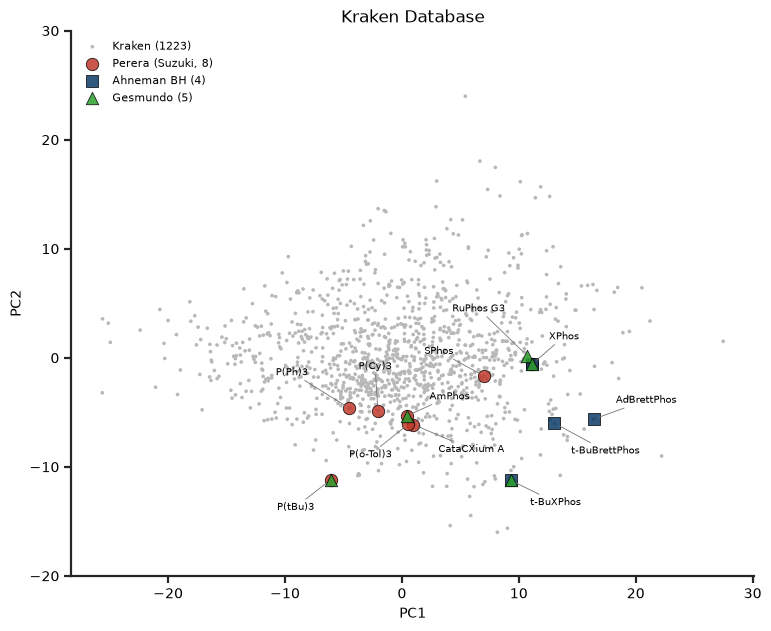

catalysts shared by more than one dataset: {'AmPhos': 216, 'P(tBu)3': 8, 'XPhos': 1, 't-BuXPhos': 90}


In [16]:
# Every dataset catalyst on the Kraken map, coloured by which screen used it.
# Same axes, scale and styling as the map above -- only the markers change.
DATASET_LABEL_OFFSETS = {           # points from the marker; tuned against the render
    "P(Ph)3": (-30, 22), "P(Cy)3": (-2, 28), "AmPhos": (16, 10),
    "P(o-Tol)3": (-12, -18), "CataCXium A": (18, -14), "P(tBu)3": (-12, -16),
    "SPhos": (-22, 14), "XPhos": (12, 16), "RuPhos G3": (-16, 30),
    "AdBrettPhos": (16, 10), "t-BuBrettPhos": (12, -16), "t-BuXPhos": (14, -12),
}

plt.close("all")
fig, ax = plt.subplots(figsize=(7.6, 6.2), constrained_layout=True)
ax.scatter(PCS.PC1, PCS.PC2, s=7, c=KRAKEN_GREY, edgecolors="none",
           label=f"Kraken ({len(PCS)})")
colors = {"Perera (Suzuki, 8)": "#c0392b", "Ahneman BH (4)": CATALYST_BLUE,
          "Gesmundo (5)": "#2ca02c"}
markers = {"Perera (Suzuki, 8)": "o", "Ahneman BH (4)": "s", "Gesmundo (5)": "^"}
for label, mapping in DATASETS.items():
    q = PCS.loc[list(mapping.values())]
    ax.scatter(q.PC1, q.PC2, s=80, c=colors[label], marker=markers[label],
               edgecolors="k", linewidths=0.6, zorder=3, label=label, alpha=0.85)

# A ligand used by two screens is one point on the map, so it is labelled once,
# under the name the first screen listing it gave.
seen = {}
for label, mapping in DATASETS.items():
    for name, kid in mapping.items():
        if kid in seen:
            continue
        seen[kid] = name
        row = PCS.loc[kid]
        place_label(ax, (row.PC1, row.PC2), name,
                    DATASET_LABEL_OFFSETS.get(name, (14, 10)),
                    fontsize=7.5, weight="normal")

ax.set(xlabel="PC1", ylabel="PC2", ylim=PC_YLIM, title="Kraken Database")
ax.legend(frameon=False, fontsize=8, loc="upper left")
thicken_axes(ax)
fig_dataset_pca = fig
display(fig_dataset_pca)
plt.close(fig_dataset_pca)

overlap = {k: v for k, v in seen.items()
           if sum(k in m.values() for m in DATASETS.values()) > 1}
print("catalysts shared by more than one dataset:",
      {seen[k]: k for k in overlap} or "none")

## Save

Nothing is written until `SAVE = True`.

In [ ]:
SAVE = False
OUT = Path.cwd() / "exports/catalyst_distance"

if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)
    for name, t in ad.items():
        t.to_csv(OUT / f"applicability_{name}.csv")
        results[name]["euclidean"].to_csv(OUT / f"pairwise_euclidean_{name}.csv")
    summary.to_csv(OUT / "knn_percentile_summary.csv")
    for label, per_set in dataset_D.items():
        for fs, D in per_set.items():
            tag = label.split()[0].lower()
            D.to_csv(OUT / f"dataset_{tag}_{fs}.csv")
    spread.to_csv(OUT / "dataset_pairwise_spread.csv", index=False)
    for fname, fig in (("pairwise", fig_pairwise), ("dendrogram", fig_dendro),
                       ("applicability", fig_ad), ("pca", fig_pca),
                       ("kraken_pc1_pc2", fig_kraken_pca),
                       ("dataset_heatmaps", fig_dataset_heat),
                       ("dataset_pca", fig_dataset_pca)):
        for ext in ("png", "pdf"):
            fig.savefig(OUT / f"{fname}.{ext}", dpi=300, bbox_inches="tight")
    print("Saved:", OUT)
else:
    print("Preview only. Set SAVE=True when ready.")